# Causal Inference-Driven Interpretable Visualization for Advertising Effect Analysis
## DRA-Net (Decision-Reliability Attribution Network) — executable research notebook

This notebook is **executable in seconds**: it loads the checkpointed results/artifacts produced by
the staged pipeline (`run_pipeline.py`) and renders every table and figure. Heavy model fitting is
shown and callable but gated by `RUN_HEAVY` (default `False`). Validation/test are the full locked
splits; the test split was scored once with all selection frozen on validation.


In [1]:
import os, sys, json
import numpy as np, pandas as pd
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
from IPython.display import Image, display
from dranet import config as C
RUN_HEAVY = False   # set True to refit (uses run_experiment stages; hours on CPU)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
def show(path, w=900):
    display(Image(path, width=w)) if os.path.exists(path) else print("missing:", path)
def load_metrics(oc): return json.load(open(f"results/metrics_{oc}.json"))
print("features:", C.FEATURES); print("splits:", C.SPLIT_TARGET)


features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
splits: {'train': 9785714, 'val': 2096939, 'test': 2096939}


## 0. Research Objective
Estimate, explain, and **act on** the incremental effect of advertising on the Criteo Uplift v2.1 RCT
(13,979,592 users). Proposed contribution: a reliability-aware decision quantity **r(x)=P(τ(x)>c)** that
drives targeting, attribution, visualization, and segmentation — tested vs point-CATE ranking, LCB
ranking, classical/meta/strong-modern/recent baselines, and a proposed network.


## 1. Literature / Methodological Context
See `RESEARCH_PLAN.md` (Parts A–B): 41 works across causal inference, uplift/advertising, interpretable
causal ML, causal visual analytics, CATE uncertainty, and policy learning. Key prior art fence:
UpliftBench (arXiv 2604.06123) already does S/T/X + Causal Forest + SHAP + persuadables on this exact
dataset — so that *combination* is explicitly not our novelty. Our contribution is the reliability
estimand r(x)=P(τ>c) as a unified policy/attribution/visualization object.


## 2. Environment and Dependencies


In [2]:
import numpy, pandas, sklearn, lightgbm, scipy, shap, econml, torch
print("numpy", numpy.__version__, "| lightgbm", lightgbm.__version__, "| torch", torch.__version__)
print("econml", econml.__version__, "| shap", shap.__version__)


/projects/sandbox/Advertisement_effect/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy 2.4.6 | lightgbm 4.7.0 | torch 2.13.0+cpu
econml 0.17.0 | shap 0.51.0


## 3. Configuration (single source of truth)


In [3]:
cfg = C.RunConfig()
print("tree_train_n =", cfg.tree_train_n, "| n_folds =", cfg.n_folds, "| seed =", cfg.seed)
print("c_grid =", cfg.c_grid, "| gamma_grid =", cfg.gamma_grid, "| alpha =", cfg.alpha)
print("VAL/TEST are FULL locked splits:", C.SPLIT_TARGET)


tree_train_n = 1000000 | n_folds = 3 | seed = 42
c_grid = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05] | gamma_grid = [0.5, 0.6, 0.7, 0.8, 0.9] | alpha = 0.1
VAL/TEST are FULL locked splits: {'train': 9785714, 'val': 2096939, 'test': 2096939}


## 4. Data Loading
Full gzip loaded once, `exposure` dropped (post-treatment mediator), float32, split 70/15/15 to
parquet. (Executed once via `dranet.data.prepare_and_save()`.)


In [4]:
from dranet import data
if RUN_HEAVY and not os.path.exists(C.split_path("train")):
    data.prepare_and_save()
rep = json.load(open(os.path.join(C.DATA_DIR, "data_validation_report.json")))
print("rows:", rep["n_rows"], "| split_counts:", rep["split_counts"])
print("treatment_mean:", round(rep["treatment_mean"], 4))
for y in C.OUTCOMES: print(f"  {y}: rate={rep[f'{y}_mean']:.5f}  naive_ATE={rep[f'{y}_naive_ate']:+.6f}")


rows: 13979592 | split_counts: {'train': 9785714, 'val': 2096939, 'test': 2096939}
treatment_mean: 0.85
  visit: rate=0.04699  naive_ATE=+0.010342
  conversion: rate=0.00292  naive_ATE=+0.001152


## 5. Data Validation
Missing/duplicate/balance/cardinality + train/val/test consistency. Note: ~1.66M identical feature
rows are an inherent property of Criteo's coarse anonymized features (documented threat to validity),
not a bug — duplicates are NOT dropped (would distort the experiment).


In [5]:
print("missing (nonzero):", {k:v for k,v in rep["missing_per_col"].items() if v>0} or "none")
print("duplicate feature-rows:", rep["n_duplicate_rows"])
print("split marginals:"); [print("  ", s, m) for s,m in rep["split_marginals"].items()]


missing (nonzero): none
duplicate feature-rows: 1663503
split marginals:
   train {'n': 9785714, 'treatment_mean': 0.8500823751848868, 'visit_mean': 0.047042556118030834, 'conversion_mean': 0.0029281460708947757}
   val {'n': 2096939, 'treatment_mean': 0.8496770769202157, 'visit_mean': 0.046780569201106945, 'conversion_mean': 0.00287228193094792}
   test {'n': 2096939, 'treatment_mean': 0.8499393639967591, 'visit_mean': 0.04696750835384339, 'conversion_mean': 0.0029075714648828604}


[None, None, None]

## 6. EDA — outcome rates & treatment imbalance


In [6]:
eda = pd.DataFrame({y: {"rate": rep[f"{y}_mean"], "rate_treated": rep[f"{y}_rate_treated"],
        "rate_control": rep[f"{y}_rate_control"], "naive_ATE": rep[f"{y}_naive_ate"]} for y in C.OUTCOMES}).T
display(eda.round(6))
print("Treatment is imbalanced (85% treated) but RANDOMIZED; conversion is extremely rare (0.29%).")


,rate,rate_treated,rate_control,naive_ATE
visit,0.046992,0.048543,0.038201,0.010342
conversion,0.002917,0.003089,0.001938,0.001152


Treatment is imbalanced (85% treated) but RANDOMIZED; conversion is extremely rare (0.29%).


## 7. Treatment / Outcome Diagnostics


In [7]:
for oc in ["visit","conversion"]:
    m = load_metrics(oc)["propensity"]
    print(f"[{oc}] propensity AUC={m['propensity_auc']:.4f} (≈0.5 ⇒ randomized) | "
          f"common support={m['frac_in_common_support']:.3f} | max|SMD|={m['max_abs_smd_before']:.4f}")


[visit] propensity AUC=0.5073 (≈0.5 ⇒ randomized) | common support=1.000 | max|SMD|=0.0467
[conversion] propensity AUC=0.5070 (≈0.5 ⇒ randomized) | common support=1.000 | max|SMD|=0.0467


## 8. Propensity Score Analysis
e(x)=P(T=1|X) for **diagnostics / doubly-robust** use only — NOT for identification (Criteo is
randomized). Stabilized IPTW, ESS, overlap reported.


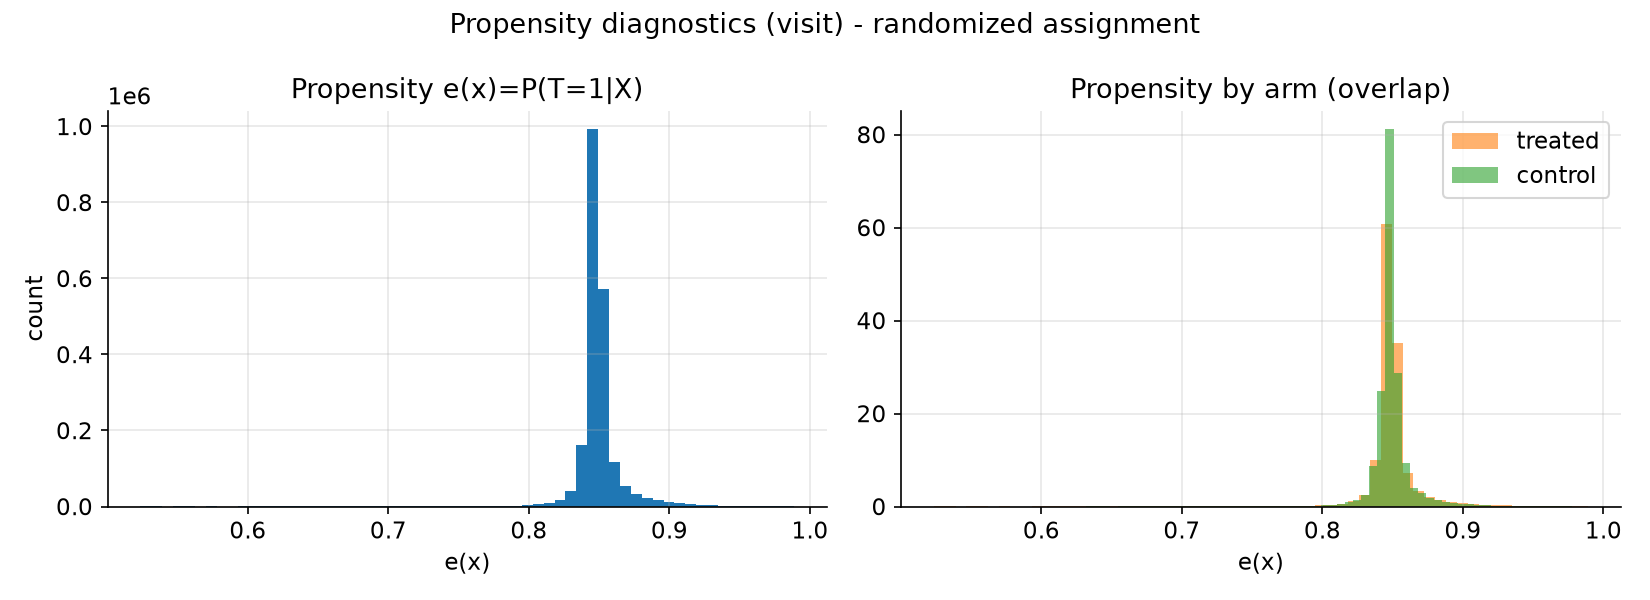

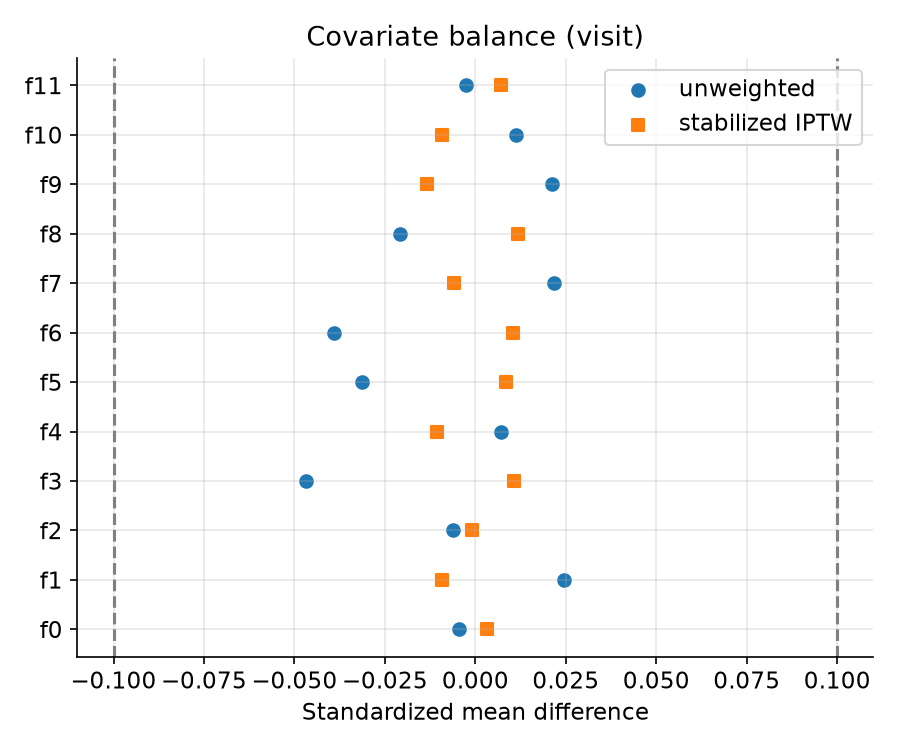

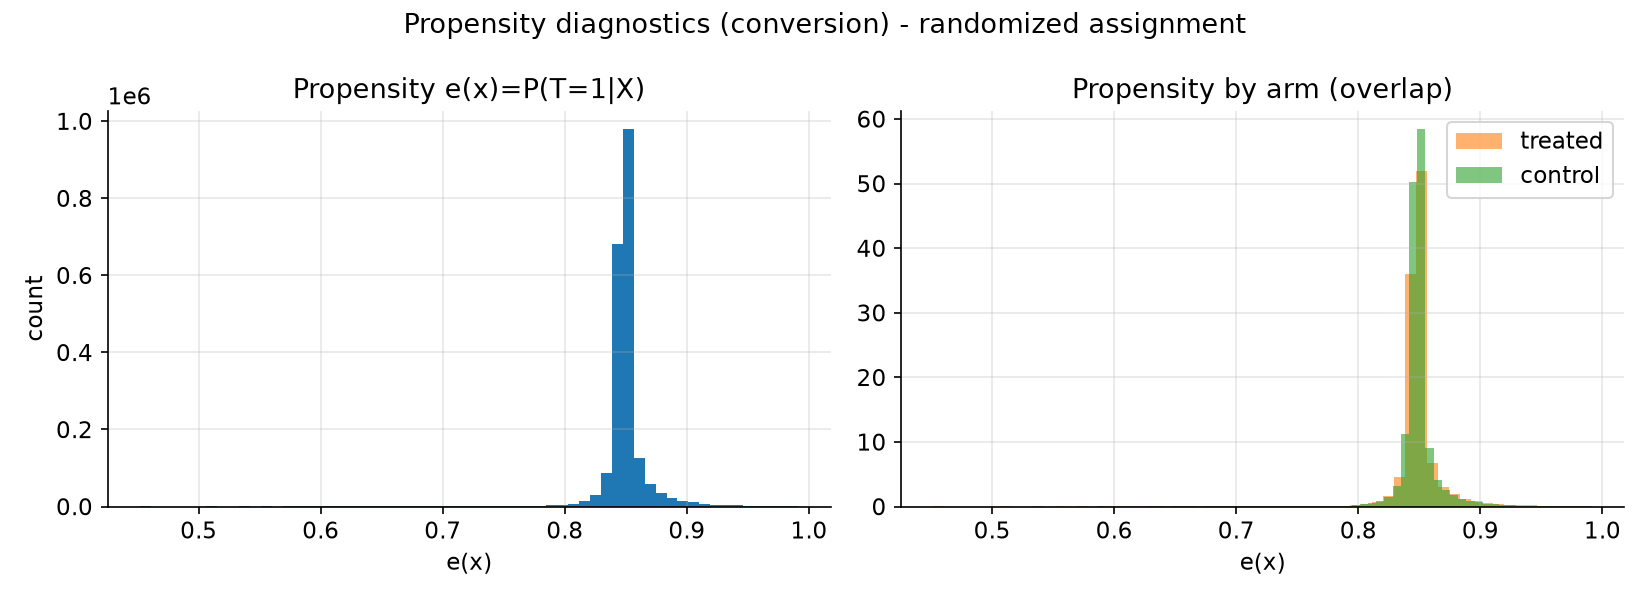

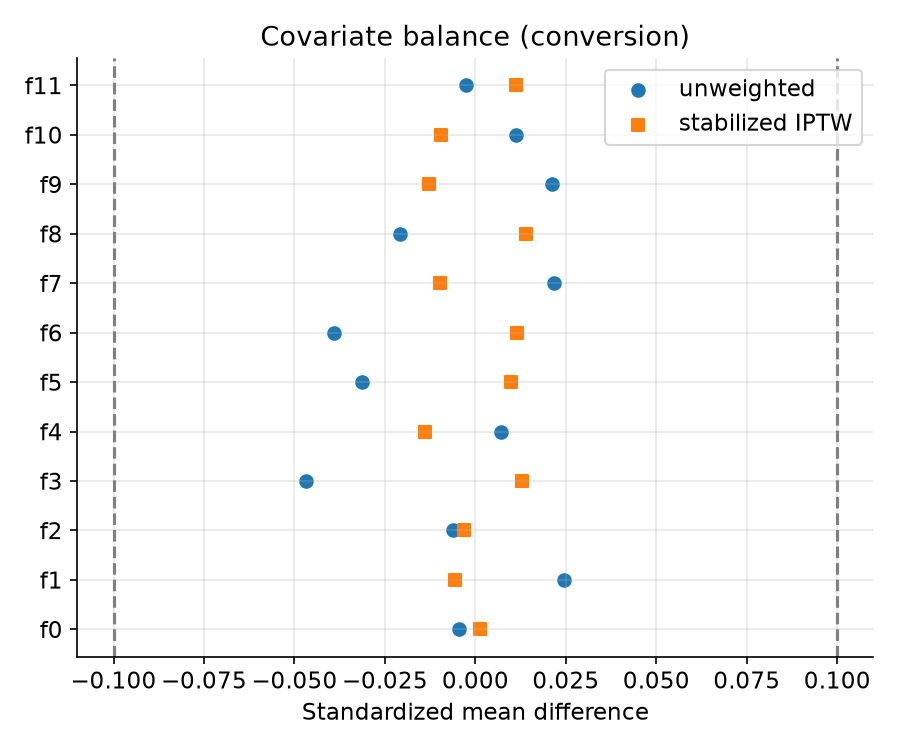

In [8]:
for oc in ["visit","conversion"]:
    show(f"plots/propensity/propensity_{oc}.png")
    show(f"plots/causal/balance_{oc}.png")


## 9. Train/Validation/Test Split (locked)


In [9]:
print("Split counts (exact):", C.SPLIT_TARGET, "-> sums to", sum(C.SPLIT_TARGET.values()))
print("Training subsample for fair comparison:", cfg.tree_train_n, "(val/test remain FULL & locked)")


Split counts (exact): {'train': 9785714, 'val': 2096939, 'test': 2096939} -> sums to 13979592
Training subsample for fair comparison: 1000000 (val/test remain FULL & locked)


## 10–16. Baselines: Naive, Logistic-interaction, S/T/X/R/DR-Learner, Class-Transformation,
Causal Forest, Uplift RF
Full implementations in `dranet.baselines` and `dranet.forests`. Fitted via
`run_pipeline.py <outcome> baselines|forests`. Below: their test metrics (loaded).


In [10]:
comp = pd.read_csv("results/comparison.csv")
show_cols = ["Model","Category","Qini","AUUC","Uplift@10%","Uplift@20%","PolicyValue","PR_AUC","CATE_CalErr"]
display(comp[comp.Outcome=="visit"][show_cols].round(4).reset_index(drop=True))


,Model,Category,Qini,AUUC,Uplift@10%,Uplift@20%,PolicyValue,PR_AUC,CATE_CalErr
0,Naive,CLASSICAL,0.0012,0.0052,0.0108,0.0101,0.0485,0.0483,0.0010
1,LogisticInteraction,CLASSICAL,0.0766,0.0083,0.0609,0.0374,0.0473,0.4633,0.0066
2,S-Learner,META,0.0893,0.0089,0.0603,0.0400,0.0480,0.5171,0.0013
3,T-Learner,META,0.0637,0.0078,0.0563,0.0365,0.0467,0.5128,0.0105
4,X-Learner,META,0.0736,0.0082,0.0570,0.0383,0.0472,0.5128,0.0079
5,R-Learner,META,0.0657,0.0079,0.0544,0.0367,0.0468,NaN,0.0087
6,DR-Learner,META,0.0520,0.0073,0.0515,0.0333,0.0461,0.5128,0.0106
7,CausalForest,STRONG_MODERN,0.0837,0.0086,0.0593,0.0397,0.0475,NaN,0.0046
8,UpliftRandomForest,STRONG_MODERN,0.0903,0.0089,0.0614,0.0389,0.0475,NaN,0.0022
9,ClassTransformation,CLASSICAL,0.0700,0.0081,0.0571,0.0359,0.0468,NaN,0.0136


## 17. Recent SOTA / strong-modern models: TARNet, CFRNet, DragonNet, DESCN-style, CHAUN-attn
PyTorch reimplementations in `dranet.neural` (trained on documented subsample, evaluated on full
locked test). Labelled STRONG_MODERN / RECENT — not indiscriminately "SOTA".


In [11]:
display(comp[(comp.Outcome=="visit") & (comp.Category.isin(["STRONG_MODERN","RECENT"]))]
        [show_cols].round(4).reset_index(drop=True))


,Model,Category,Qini,AUUC,Uplift@10%,Uplift@20%,PolicyValue,PR_AUC,CATE_CalErr
0,CausalForest,STRONG_MODERN,0.0837,0.0086,0.0593,0.0397,0.0475,NaN,0.0046
1,UpliftRandomForest,STRONG_MODERN,0.0903,0.0089,0.0614,0.0389,0.0475,NaN,0.0022
2,TARNet,STRONG_MODERN,0.0939,0.0091,0.0672,0.0403,0.0481,0.5160,0.0023
3,CFRNet,STRONG_MODERN,0.0906,0.0089,0.0616,0.0398,0.0479,0.5142,0.0013
4,DragonNet,STRONG_MODERN,0.0865,0.0088,0.0536,0.0382,0.0478,0.5141,0.0096
5,DESCN-style,RECENT,0.0710,0.0081,0.0651,0.0381,0.0467,0.5111,0.0084
6,CHAUN-attn,RECENT,0.0787,0.0084,0.0597,0.0391,0.0475,0.5119,0.0028


## 18. Proposed Model — DRA-Net
`r(x)=P(τ(x)>c)=Φ((τ̃(x)−c)/(κ s(x)))`. Backbone: cross-fitted AIPW/DR-Learner; uncertainty:
heterogeneous conditional dispersion; calibration: isotonic GATES; c,κ,γ selected on validation.


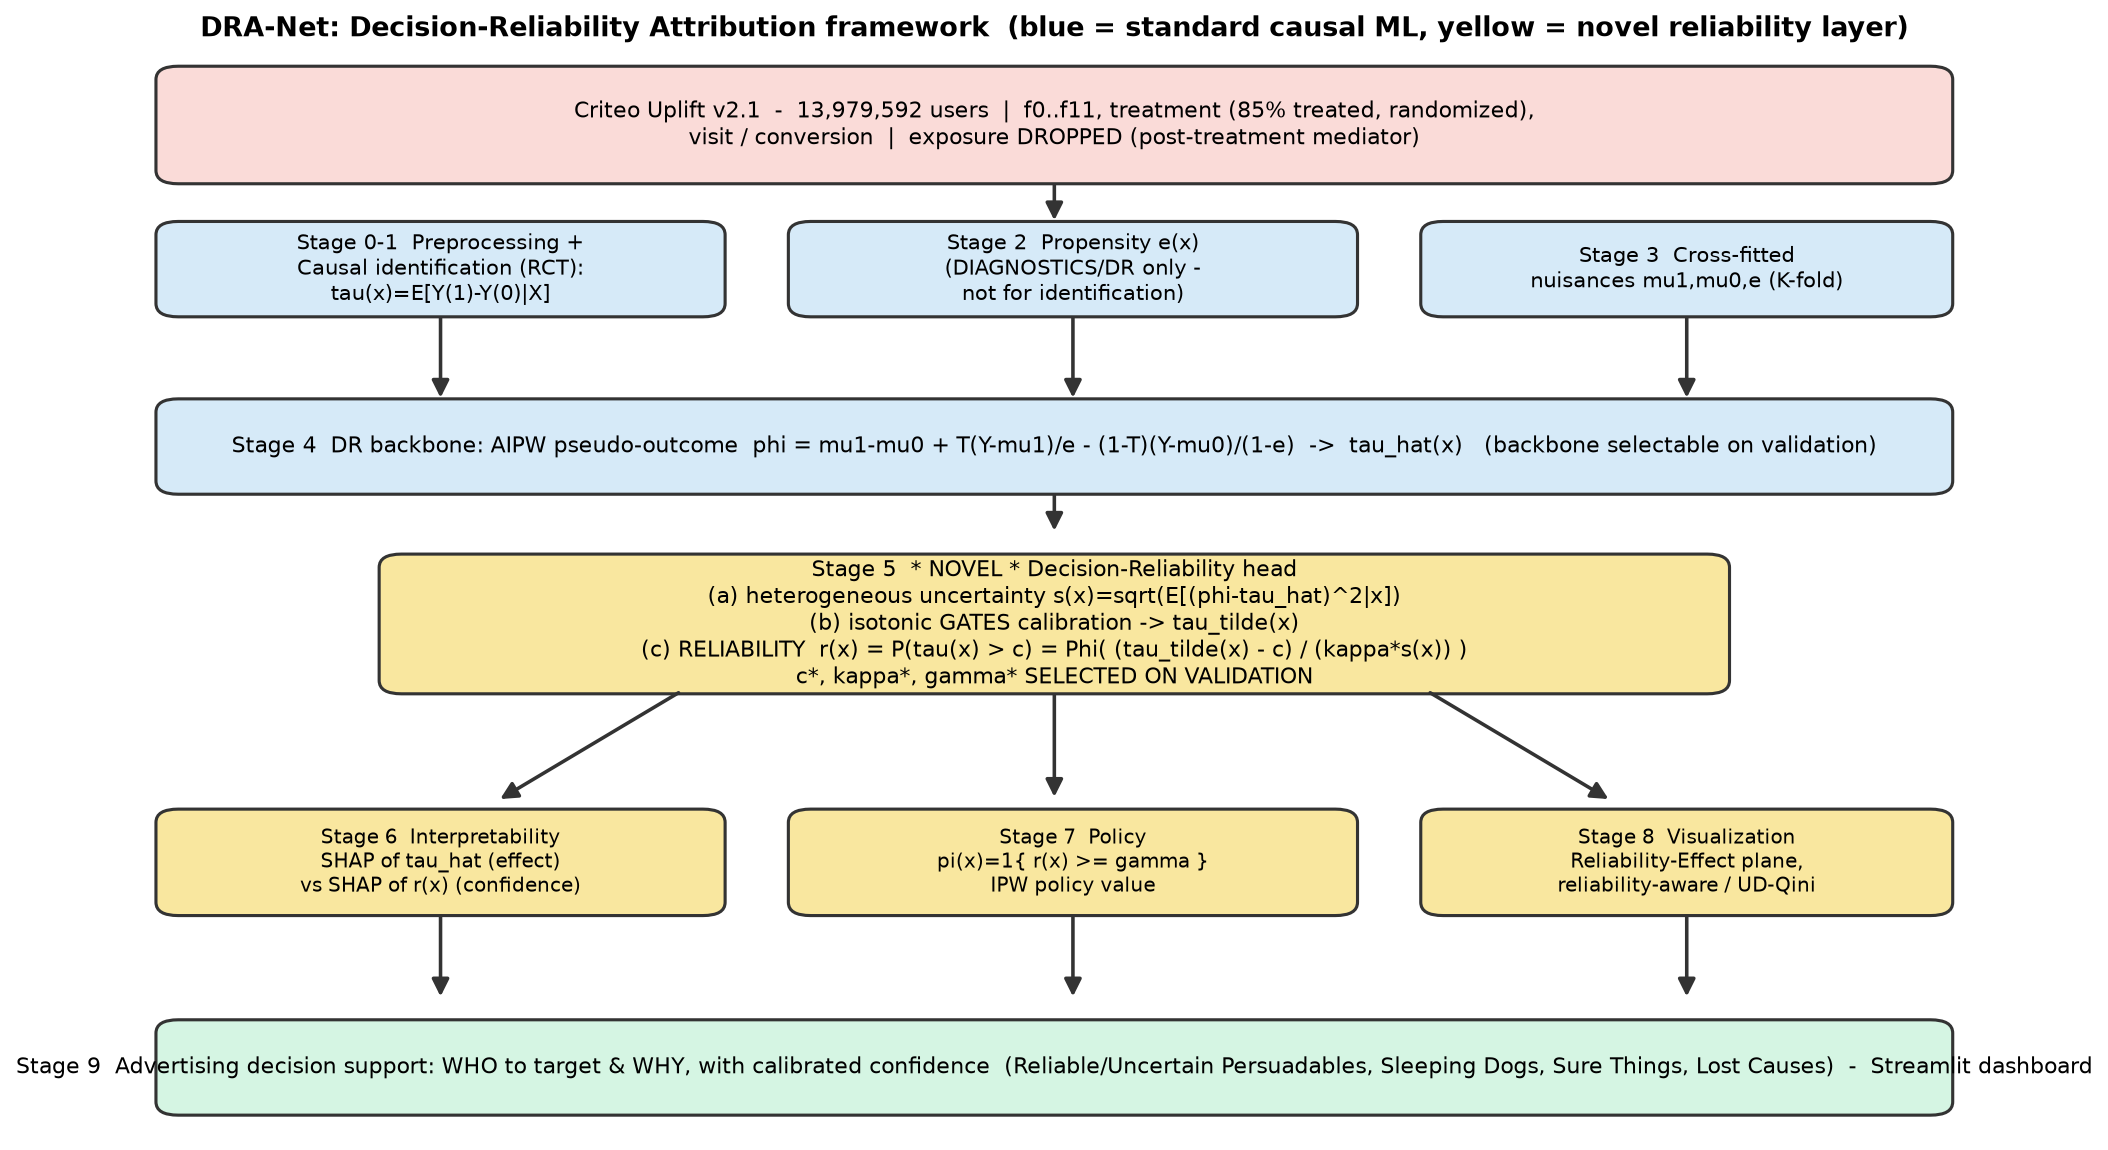

[visit] c*=0.02 kappa*=0.0346 gamma*=0.5 | val AUUC: reliability=0.00898 vs CATE=0.00808
[conversion] c*=0.001024 kappa*=0.5287 gamma*=0.5 | val AUUC: reliability=0.00090 vs CATE=0.00079


In [12]:
show("plots/comparison/dranet_architecture.png", w=1100)
for oc in ["visit","conversion"]:
    s = load_metrics(oc)["dranet_selection"]
    print(f"[{oc}] c*={s['c_star']} kappa*={s['kappa_star']:.4f} gamma*={s['gamma_star']} "
          f"| val AUUC: reliability={s['val_auuc_reliability']:.5f} vs CATE={s['val_auuc_cate']:.5f}")


## 19. Hyperparameter tuning (LightGBM defaults; c,κ,γ grids)


In [13]:
print("LightGBM:", cfg.lgbm_params)
print("Reliability grids: c_grid=", cfg.c_grid, "gamma_grid=", cfg.gamma_grid)


LightGBM: {'objective': 'binary', 'n_estimators': 400, 'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 200, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'n_jobs': 8, 'verbose': -1}
Reliability grids: c_grid= [0.0, 0.005, 0.01, 0.02, 0.03, 0.05] gamma_grid= [0.5, 0.6, 0.7, 0.8, 0.9]


## 20. Validation-based model selection
c, κ, γ and the DRA-Net backbone are chosen on validation (never test). Backbone-generality analysis
(`dranet.backbone_analysis`) selects the val-best backbone for DRA-Net*.


In [14]:
for oc in ["visit","conversion"]:
    bg = json.load(open(f"results/backbone_generality_{oc}.json"))
    print(f"[{oc}] validation-selected backbone = {bg['selected_backbone']} | "
          f"test Qini: r={bg['test_qini_r']:.4f} vs tau={bg['test_qini_tau']:.4f}")


[visit] validation-selected backbone = TARNet | test Qini: r=0.0910 vs tau=0.0923
[conversion] validation-selected backbone = CFRNet | test Qini: r=0.1504 vs tau=0.1568


## 21. Causal Evaluation — ATE / CATE


In [15]:
display(comp[comp.Outcome=="visit"][["Model","ATE","CATE_Mean","CATE_Std","CATE_CalErr","Pos_CATE_%","Neg_CATE_%"]]
        .round(5).reset_index(drop=True))


,Model,ATE,CATE_Mean,CATE_Std,CATE_CalErr,Pos_CATE_%,Neg_CATE_%
0,Naive,0.01029,0.01029,0.00000,0.00104,1.00000,0.00000
1,LogisticInteraction,0.00750,0.00750,0.04128,0.00664,0.49536,0.50464
2,S-Learner,0.00711,0.00711,0.02387,0.00135,0.91141,0.08859
3,T-Learner,0.00777,0.00777,0.04278,0.01045,0.75479,0.24521
4,X-Learner,0.00734,0.00734,0.03793,0.00791,0.88514,0.11486
5,R-Learner,0.00735,0.00735,0.04591,0.00872,0.94252,0.05748
6,DR-Learner,0.00730,0.00730,0.05878,0.01062,0.95031,0.04969
7,CausalForest,0.00629,0.00629,0.01930,0.00456,0.75848,0.24152
8,UpliftRandomForest,0.00927,0.00927,0.02192,0.00225,0.91062,0.08938
9,ClassTransformation,0.01022,0.01022,0.07330,0.01356,0.95898,0.04102


## 22. Prediction Diagnostics (supporting only — accuracy is NOT the headline)


In [16]:
display(comp[comp.Outcome=="visit"][["Model","PR_AUC","ROC_AUC","F1","Brier"]].round(4).reset_index(drop=True))
print("Criteo is highly imbalanced; PR-AUC/Brier are supporting diagnostics, not the primary result.")


,Model,PR_AUC,ROC_AUC,F1,Brier
0,Naive,0.0483,0.5146,0.0000,0.0447
1,LogisticInteraction,0.4633,0.9342,0.3798,0.0323
2,S-Learner,0.5171,0.9466,0.4303,0.0298
3,T-Learner,0.5128,0.9459,0.4277,0.0299
4,X-Learner,0.5128,0.9459,0.4277,0.0299
5,R-Learner,NaN,NaN,NaN,NaN
6,DR-Learner,0.5128,0.9459,0.4277,0.0299
7,CausalForest,NaN,NaN,NaN,NaN
8,UpliftRandomForest,NaN,NaN,NaN,NaN
9,ClassTransformation,NaN,NaN,NaN,NaN


Criteo is highly imbalanced; PR-AUC/Brier are supporting diagnostics, not the primary result.


## 23. Interpretability — effect vs confidence (two distinct questions)
SHAP of τ̂(x) = *why the ad helps*; SHAP of the reliability score = *why we are confident*.


visit


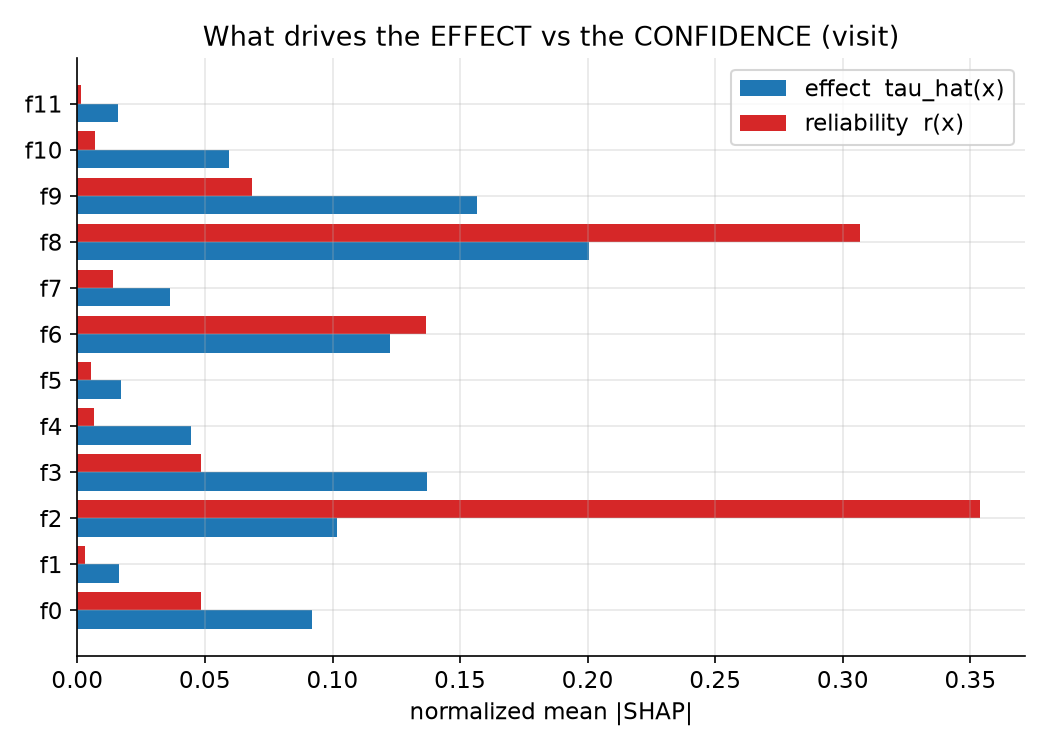

conversion


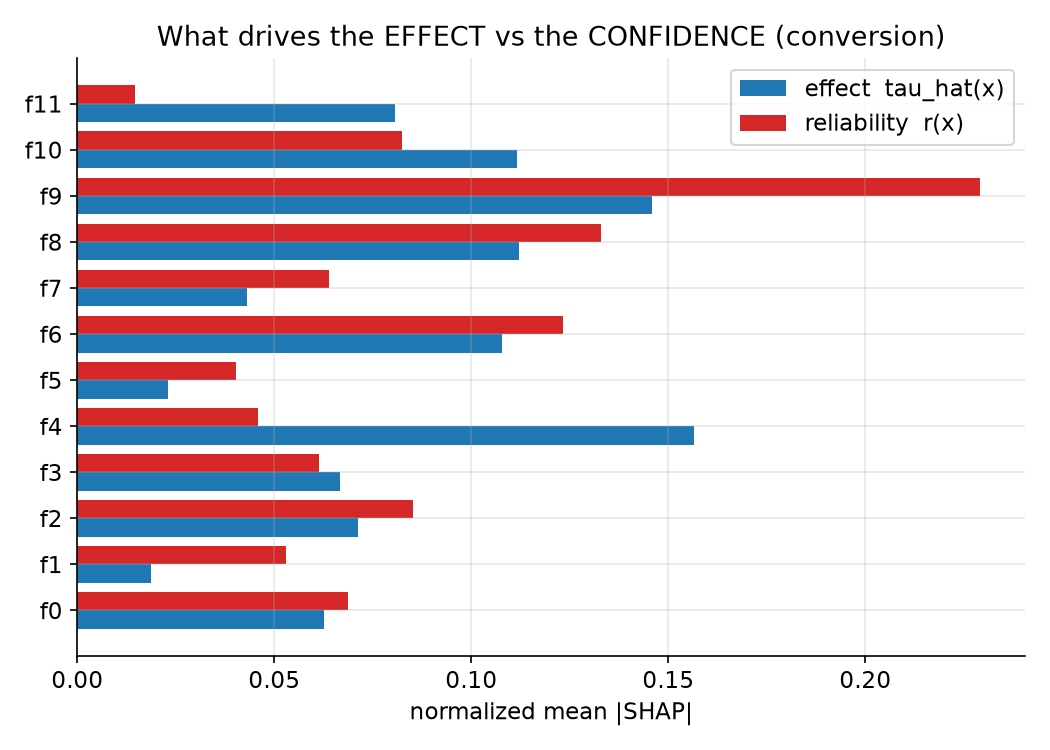

reliability-score surrogate R2 (visit): 0.972


In [17]:
for oc in ["visit","conversion"]:
    print(oc); show(f"plots/interpretability/effect_vs_reliability_shap_{oc}.png")
sh = json.load(open("results/metrics_visit.json"))  # surrogate fidelity noted in shap_summary
try:
    ss = json.load(open("artifacts/visit/shap_summary.json"))
    print("reliability-score surrogate R2 (visit):", round(ss["surrogate_r2"],3))
except Exception: pass


## 24. Visualization — CATE, Qini, uplift, policy


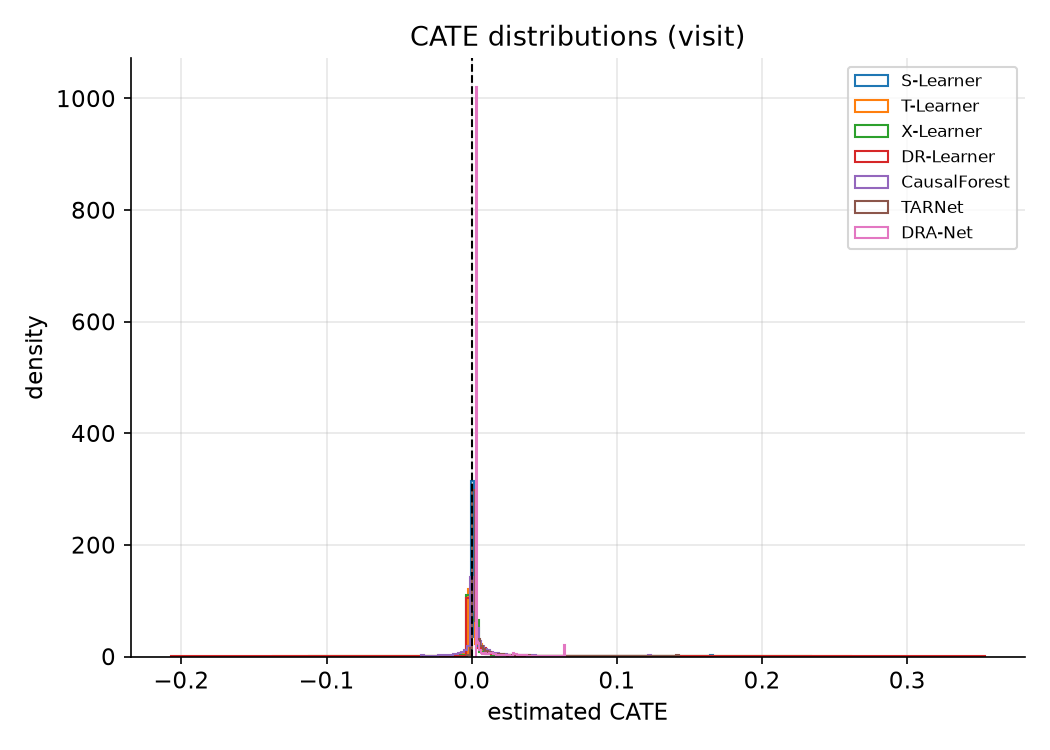

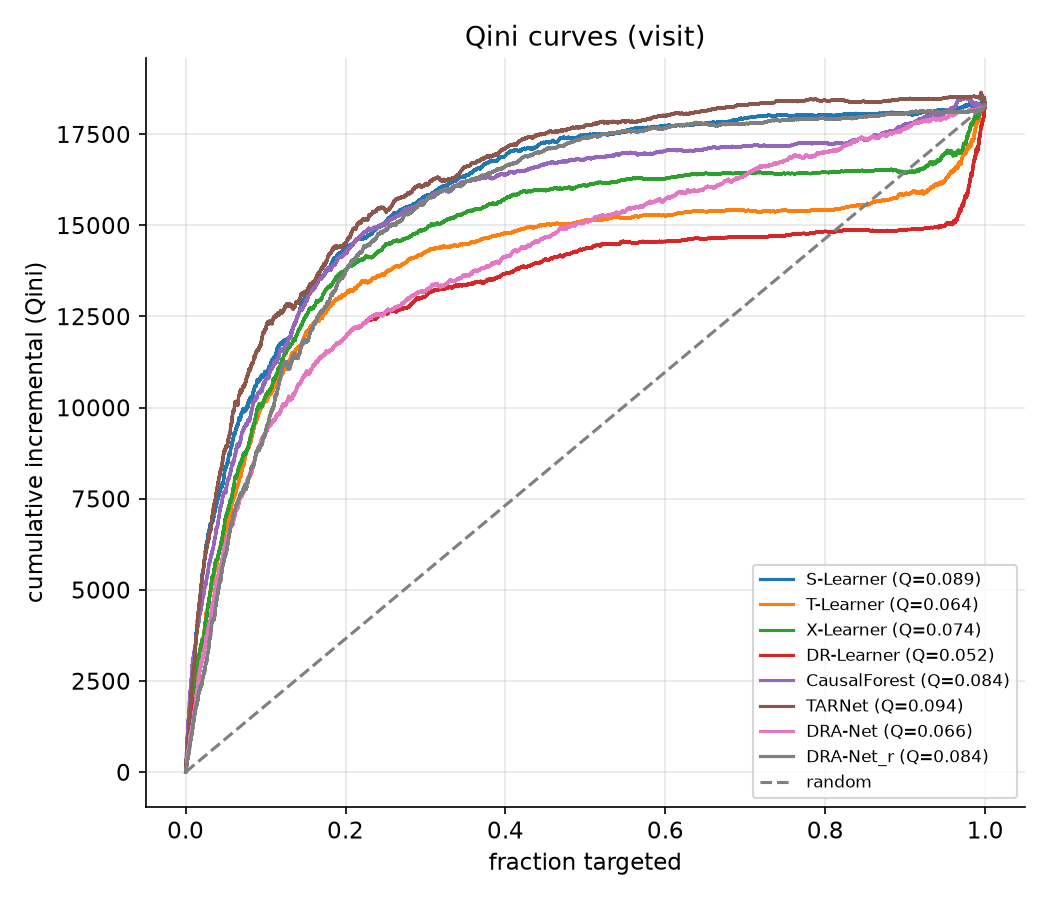

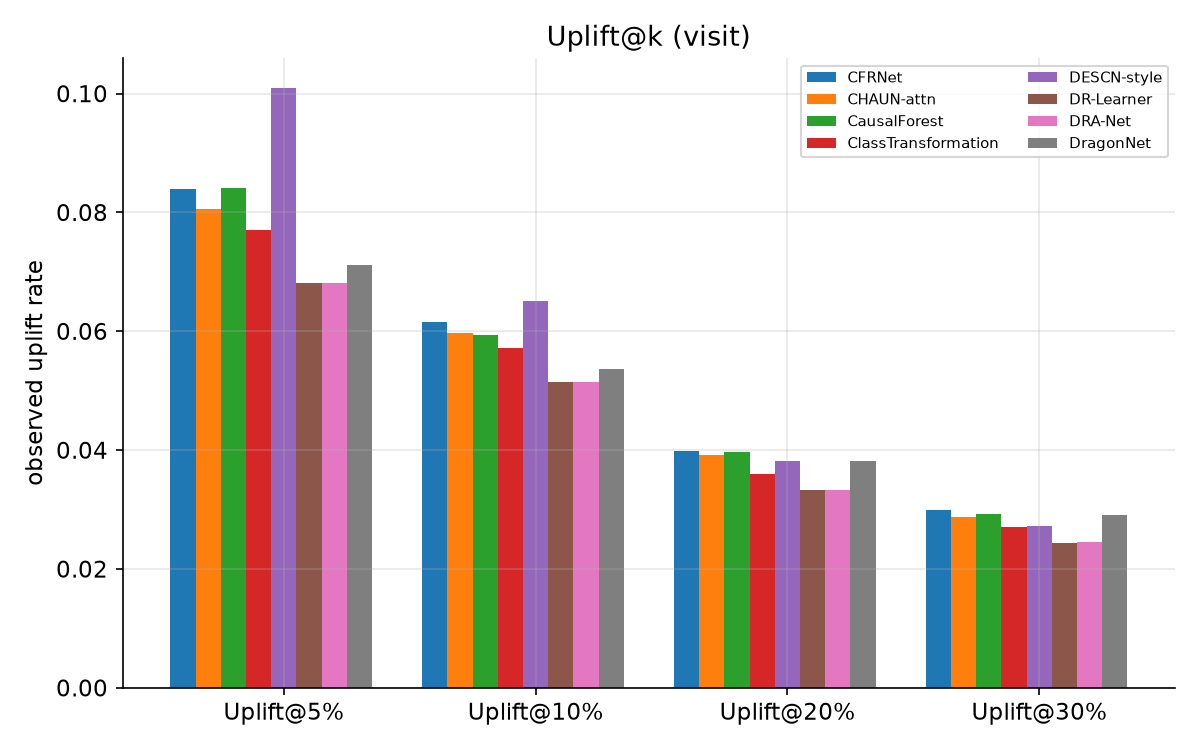

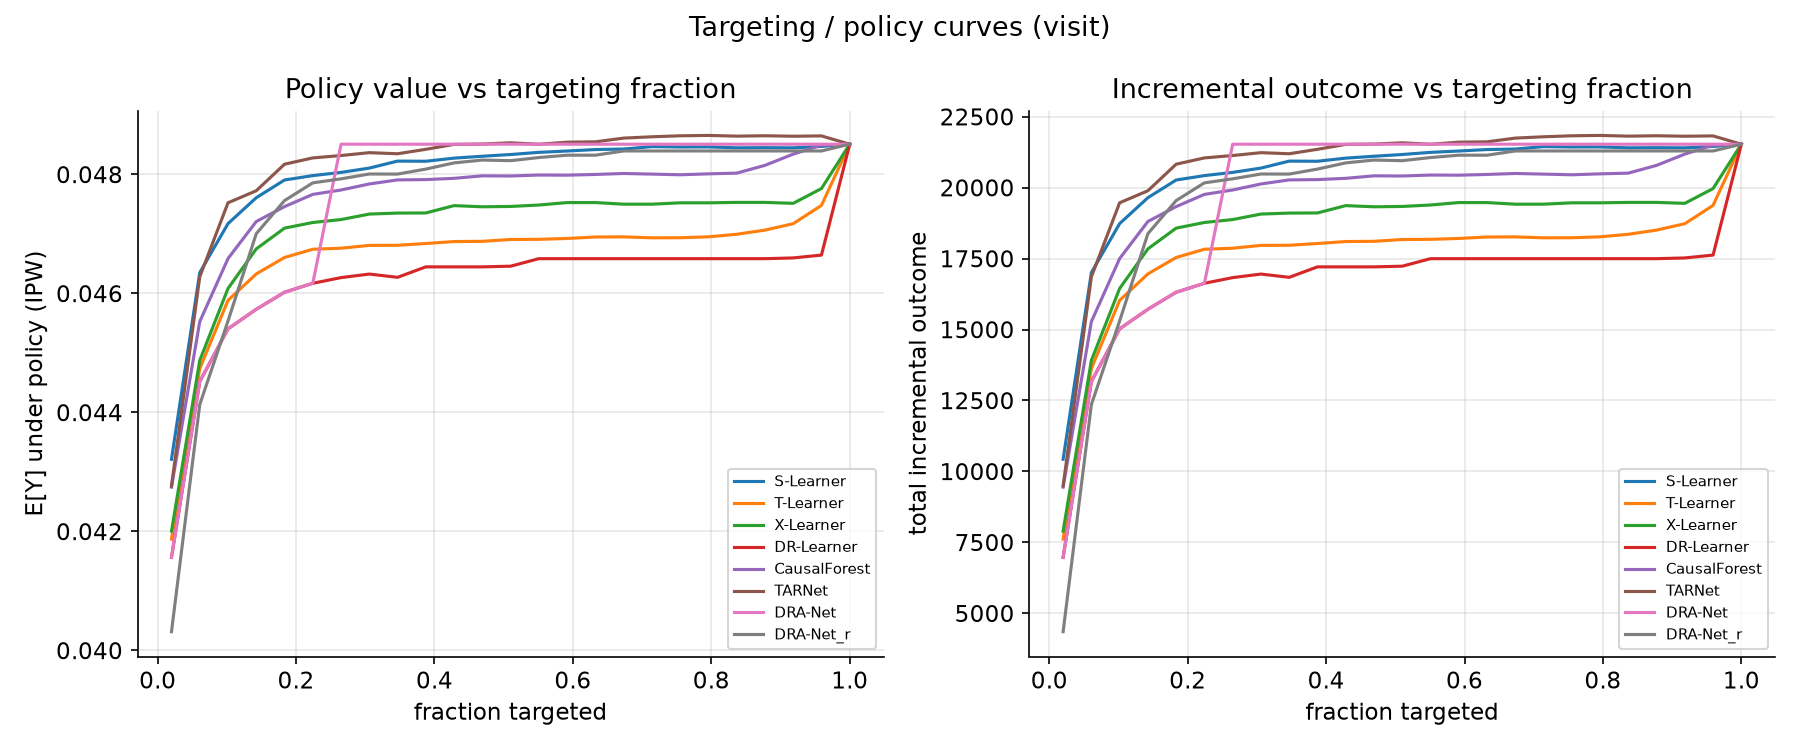

In [18]:
oc="visit"
for p in [f"plots/cate/cate_distributions_{oc}.png", f"plots/qini/qini_curves_{oc}.png",
          f"plots/uplift/uplift_at_k_{oc}.png", f"plots/policy/targeting_curves_{oc}.png"]:
    show(p)


## 25. Ablation Study (A0–A10)


,ablation,Qini,AUUC,Uplift@20%,PolicyValue,TargetFrac
0,A0_full,0.0030,0.0087,0.0383,0.0452,0.0891
1,A1_no_reliability,0.0024,0.0079,0.0333,0.0452,0.0891
2,A2_raw_cate,0.0024,0.0079,0.0333,0.0452,0.0891
3,A3_no_uncertainty,0.0022,0.0077,0.0319,0.0452,0.0891
4,A4_no_threshold_c,0.0009,0.0062,0.0256,0.0485,1.0000
5,A5_no_attribution,0.0030,0.0087,0.0383,0.0452,0.0891
6,A6_no_calibration,0.0030,0.0087,0.0383,0.0452,0.0891
7,A7_fixed_threshold,0.0009,0.0062,0.0256,0.0485,1.0000
8,A8_c=0.005,0.0029,0.0086,0.0372,0.0460,0.1724
9,A8_c=0.05,0.0030,0.0086,0.0384,0.0421,0.0248


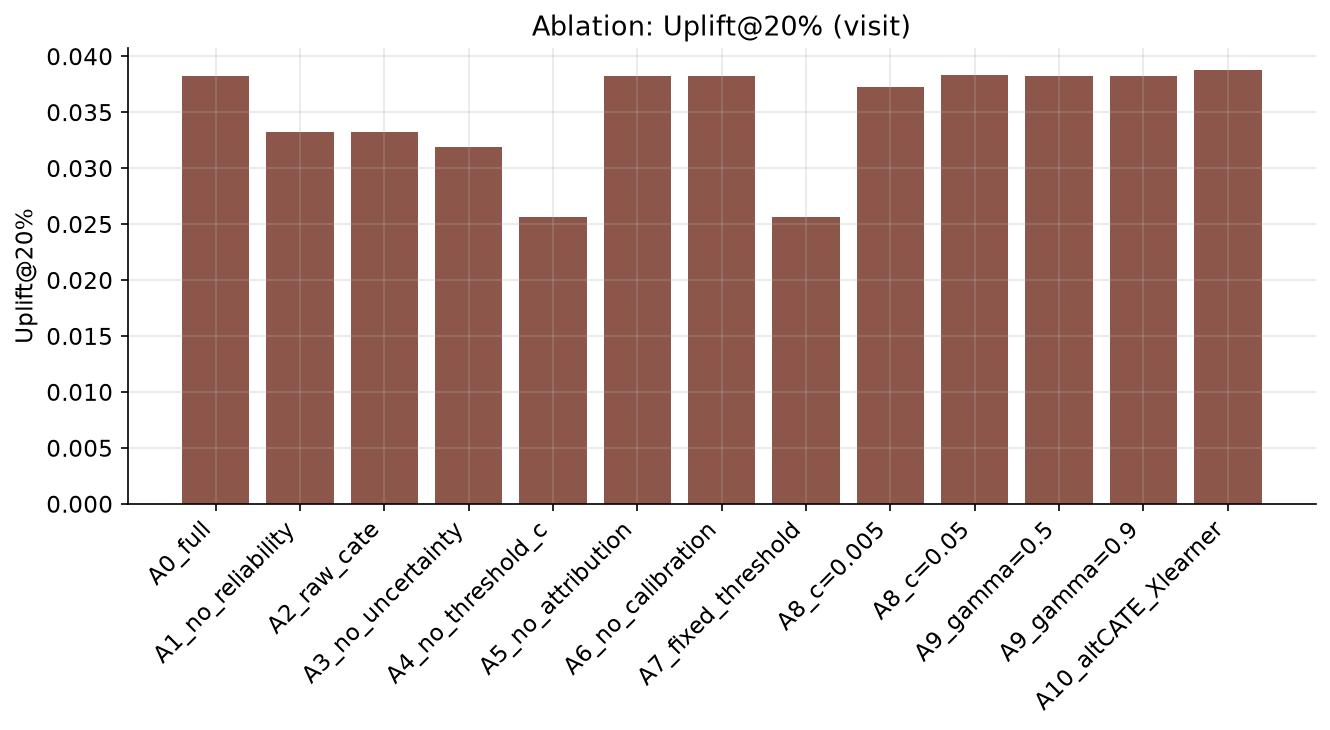

In [19]:
abl = pd.read_csv("results/ablation_visit.csv")
display(abl[["ablation","Qini","AUUC","Uplift@20%","PolicyValue","TargetFrac"]].round(4))
show("plots/ablation/ablation_Uplift@20%_visit.png")


## 26. Robustness / Statistical Significance (bootstrap, paired)


In [20]:
for oc in ["visit","conversion"]:
    r = load_metrics(oc); bb = r["best_baseline_by_qini"]
    d = r["significance"]["diff_vs_first"]
    print(f"\n[{oc}] reference=DRA-Net_r ; diff = (other - DRA-Net_r). best baseline={bb}")
    for other in [bb, "DRA-Net_CATE"]:
        q = d.get(other,{}).get("qini",{})
        if q: print(f"  {other}: Δqini={q['mean_diff']:+.5f} 95%CI[{q['lo95']:+.5f},{q['hi95']:+.5f}] sig={q['significant_95']}")



[visit] reference=DRA-Net_r ; diff = (other - DRA-Net_r). best baseline=TARNet
  TARNet: Δqini=+0.00035 95%CI[+0.00020,+0.00053] sig=True
  DRA-Net_CATE: Δqini=-0.00066 95%CI[-0.00084,-0.00047] sig=True

[conversion] reference=DRA-Net_r ; diff = (other - DRA-Net_r). best baseline=CFRNet
  CFRNet: Δqini=+0.00005 95%CI[+0.00002,+0.00008] sig=True
  DRA-Net_CATE: Δqini=-0.00010 95%CI[-0.00015,-0.00004] sig=True


## 27. Final Test Evaluation (once, frozen) + the decisive comparison
Does r(x) beat point-CATE and LCB ranking on the SAME backbone?


In [21]:
for oc in ["visit","conversion"]:
    dec = load_metrics(oc)["decisive_comparison"]
    print(f"\n[{oc}] targeting fraction={dec['dranet_targeting_fraction']:.3f}")
    for rule in ["CATE_tau_hat","LCB","P(tau>c)=r"]:
        v = dec[rule]; print(f"  {rule:14s} Qini={v['qini_coef_normalized']:+.4f} u@20={v['uplift@20']:.5f}")



[visit] targeting fraction=0.089
  CATE_tau_hat   Qini=+0.0656 u@20=0.03329
  LCB            Qini=-0.0533 u@20=0.00903
  P(tau>c)=r     Qini=+0.0838 u@20=0.03826

[conversion] targeting fraction=0.047
  CATE_tau_hat   Qini=+0.0909 u@20=0.00292
  LCB            Qini=-0.0730 u@20=0.00141
  P(tau>c)=r     Qini=+0.1359 u@20=0.00408


## 28. Master Comparison Table (both outcomes; DRA-Net family included)


In [22]:
cols = ["Model","Outcome","Category","Qini","AUUC","Uplift@20%","PolicyValue","PR_AUC",
        "Coverage","IntervalWidth","ReliablePos_%","Uncertain_%"]
display(comp[cols].round(4))


,Model,Outcome,Category,Qini,AUUC,Uplift@20%,PolicyValue,PR_AUC,Coverage,IntervalWidth,ReliablePos_%,Uncertain_%
0,Naive,conversion,CLASSICAL,0.0044,0.0005,0.0010,0.0031,0.0030,NaN,NaN,NaN,NaN
1,LogisticInteraction,conversion,CLASSICAL,0.1295,0.0008,0.0038,0.0029,0.1836,NaN,NaN,NaN,NaN
2,S-Learner,conversion,META,0.1253,0.0008,0.0039,0.0029,0.2048,NaN,NaN,NaN,NaN
3,T-Learner,conversion,META,0.1272,0.0008,0.0040,0.0029,0.1938,NaN,NaN,NaN,NaN
4,X-Learner,conversion,META,0.0857,0.0007,0.0035,0.0028,0.1938,NaN,NaN,NaN,NaN
5,R-Learner,conversion,META,0.0693,0.0007,0.0032,0.0028,NaN,NaN,NaN,NaN,NaN
6,DR-Learner,conversion,META,0.0486,0.0006,0.0030,0.0027,0.1938,NaN,NaN,NaN,NaN
7,CausalForest,conversion,STRONG_MODERN,0.1350,0.0008,0.0041,0.0029,NaN,NaN,NaN,NaN,NaN
8,UpliftRandomForest,conversion,STRONG_MODERN,0.1233,0.0008,0.0038,0.0029,NaN,NaN,NaN,NaN,NaN
9,ClassTransformation,conversion,CLASSICAL,0.0615,0.0007,0.0031,0.0028,NaN,NaN,NaN,NaN,NaN


## 29. Save Best Model (frozen artifacts)


In [23]:
import glob
print("models/:", [os.path.relpath(p, ".") for p in glob.glob("models/**/*", recursive=True) if os.path.isfile(p)])
print("metadata:", json.load(open("models/dranet/metadata_visit.json")))


models/: ['models/dranet/point_model_visit.joblib', 'models/dranet/var_model_visit.joblib', 'models/dranet/isotonic_visit.joblib', 'models/dranet/nuisances_visit.joblib', 'models/dranet/metadata_visit.json', 'models/propensity/propensity_visit.joblib', 'models/propensity/propensity_conversion.joblib', 'models/preprocessing/preprocessing.json', 'models/calibration/isotonic_gates_visit.joblib']
metadata: {'outcome': 'visit', 'c_star': 0.02, 'kappa_star': 0.03455450059168243, 'gamma_star': 0.5, 'z': 1.6448536269514722, 'alpha': 0.1, 'features': ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11'], 'seed': 42, 'n_folds': 3, 'tree_train_n': 1000000, 'model_version': 'DRA-Net-0.1.0', 'split_counts': {'train': 9785714, 'val': 2096939, 'test': 2096939}, 'selection': {'c_star': 0.02, 'kappa_star': 0.03455450059168243, 'gamma_star': 0.5, 'z': 1.6448536269514722, 'group_coverage_val': 1.0, 'val_auuc_cate': 0.008081564206968555, 'val_auuc_reliability': 0.00898115333056604, 's

## 30. Export Results


In [24]:
print("results/:", sorted(os.listdir("results")))


results/: ['ablation.csv', 'ablation_conversion.csv', 'ablation_visit.csv', 'backbone_generality_conversion.csv', 'backbone_generality_conversion.json', 'backbone_generality_visit.csv', 'backbone_generality_visit.json', 'cate_predictions.csv', 'cate_predictions_conversion.csv', 'cate_predictions_visit.csv', 'causal_metrics.csv', 'causal_metrics_conversion.csv', 'causal_metrics_visit.csv', 'comparison.csv', 'comparison_conversion.csv', 'comparison_visit.csv', 'metrics_conversion.json', 'metrics_visit.json', 'policy_metrics.csv', 'policy_metrics_conversion.csv', 'policy_metrics_visit.csv', 'policy_results_conversion.csv', 'policy_results_visit.csv', 'reliability_metrics.csv', 'reliability_metrics_conversion.csv', 'reliability_metrics_visit.csv', 'test_predictions.csv', 'test_predictions_conversion.csv', 'test_predictions_visit.csv', 'uplift_metrics.csv', 'uplift_metrics_conversion.csv', 'uplift_metrics_visit.csv']


## 31. Streamlit Dashboard Preparation
`PYTHONPATH=src streamlit run app/streamlit_app.py` — 7 pages: overview, causal diagnostics, CATE,
targeting, model comparison, individual user explanation (live), interpretation summary.


In [25]:
print(open("app/streamlit_app.py").read()[:600], "...")


"""
DRA-Net interactive dashboard — the "Interpretable Visualization" component of
"Causal Inference-Driven Interpretable Visualization for Advertising Effect Analysis".

Run:
    cd Advertisement_effect
    PYTHONPATH=src .venv/bin/streamlit run app/streamlit_app.py

Reads saved results/ + plots/ + artifacts/ (no retraining). Page 6 loads the frozen
DRA-Net object for live per-user counterfactual + reliability computation.

DISCLAIMER shown in-app: estimates are causal only insofar as Criteo's randomized design
and the estimator assumptions hold; reliability r(x)=P(tau>c) is a validated DECIS ...


## 32. Final Research Summary
See `REPORT/RESEARCH_SUMMARY.md`. Headline (honest): reliability ranking r(x)=P(τ>c) **significantly
beats point-CATE and LCB ranking on the same backbone**, with the largest gains on noisy estimators
and no-harm behaviour on strong ones; DRA-Net on the DR backbone does **not** beat the best neural
baseline in absolute Qini (reported transparently), while DRA-Net* (validation-selected backbone) is
on par with it and adds calibrated confidence, segmentation, and dual attribution.


In [26]:
print(open("REPORT/RESEARCH_SUMMARY.md").read()[:1500])


# Causal Inference-Driven Interpretable Visualization for Advertising Effect Analysis
## Final Research Summary — DRA-Net (Decision-Reliability Attribution Network)

*All numbers below are computed on the real Criteo Uplift v2.1 data (13,979,592 rows). The
final test split (2,096,939 rows) was scored once, after all model/threshold selection was
frozen on validation. Where the proposed method does not beat a baseline, this is stated
explicitly — no superiority is manufactured.*

---

## 1. Research problem
Digital advertisers must decide **whom to treat** (show ads) to maximize *incremental* outcomes,
not predicted outcomes. This requires per-user causal effect estimates and, crucially, a
**decision** built on them. Standard practice ranks users by a point estimate of the conditional
average treatment effect (CATE) `τ̂(x)`, ignoring how *reliable* each estimate is.

## 2. Existing limitation
Across the uplift / advertising causal-ML literature, the object that is ranked, explained, and